In [27]:
import cpi
import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

In [8]:
def test_autocorrelation(x, n_lags=40, alpha=0.05, h0_type='c'):
    adf_results = adf_test(x)
    kpss_results = kpss_test(x, h0_type=h0_type)

    print('ADF test statistic: {:.2f} (p-val: {:.2f})'.format(adf_results['Test Statistic'],
                                                             adf_results['p-value']))
    print('KPSS test statistic: {:.2f} (p-val: {:.2f})'.format(kpss_results['Test Statistic'],
                                                              kpss_results['p-value']))

    fig, ax = plt.subplots(2, figsize=(16, 8))
    plot_acf(x, ax=ax[0], lags=n_lags, alpha=alpha)
    plot_pacf(x, ax=ax[1], lags=n_lags, alpha=alpha)

    return fig

### 데이터 불러오기(금시세 2000~2011년도)

In [30]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GC=F"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")


df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               # Date를 인덱스로 설정
df = df.loc['2000-01-01':'2011-12-31']  # 분석 기간
df = df['Close'].resample('ME').mean()  # 월평균 가격 계산
df = df.to_frame(name='price')          # 컬럼명 변경

df['dt_index'] = df.index.map(lambda x: x.to_pydatetime().date())

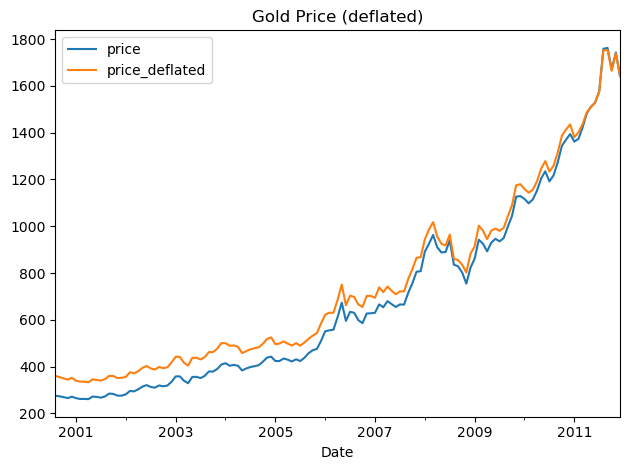

In [31]:
#인플레이션 정보 조회
series = cpi.series.get()

cpi_df = series.to_dataframe()
cpi_df['date'] = pd.to_datetime(cpi_df['date'])
cpi_df = cpi_df[['date', 'value']].set_index('date')

defl_date = pd.Timestamp('2011-12-31')

#기준 일자 CPI값
target_cpi = cpi_df.loc[
    cpi_df.index.to_period('M') == defl_date.to_period('M'),
    'value'
].iloc[0]

#월별 금가격에 CPI맵핑
df['cpi'] = df.index.to_period('M').map(
    cpi_df['value'].groupby(cpi_df.index.to_period('M')).mean()
)

## 인플레이션 보정 가격 계산
df['price_deflated'] = (
    df['price'] * target_cpi / df['cpi']
)

df[['price', 'price_deflated']].plot(title='Gold Price (deflated)')

plt.tight_layout()
plt.show()